In [1]:
import numpy as np
import torch
from torch import nn
import torchvision
import torchvision.models as models
from torchvision.transforms import v2

import matplotlib.pyplot as plt
from PIL import Image

In [39]:
model = models.resnet34(weights="DEFAULT")

In [40]:
img = Image.open("../data_/car.jpg")

In [41]:
transforms = models.ResNet34_Weights.DEFAULT.transforms()
class_names = models.ResNet34_Weights.DEFAULT.meta["categories"]

tensor(817)

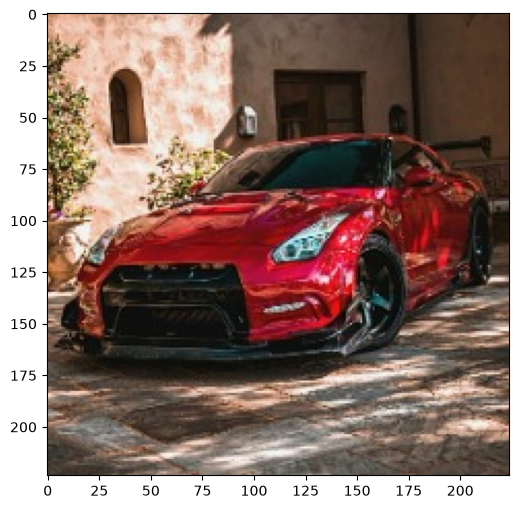

In [42]:
plt.imshow(img)

model.eval()
img_in = transforms(img).unsqueeze(dim=0)
pred = model(img_in).squeeze()

pred.argmax()

In [43]:
print(class_names[817])
cl = 817

sports car


In [44]:
new_model = nn.Sequential(
    model.conv1,
    model.bn1,
    model.relu,
    model.maxpool,
    model.layer1,
    model.layer2,
    model.layer3,
    model.layer4
)

In [45]:
weights = model.fc.state_dict()["weight"][cl]
weights.shape

torch.Size([512])

C:\Users\1\AppData\Local\Temp\ipykernel_17684\2207159180.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  img1 = np.transpose(img1, axes=[1, 2, 0]) * np.array([[[0.229, 0.224, 0.225]]]) + np.array([[[0.485, 0.456, 0.406]]])
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9999999964237213].


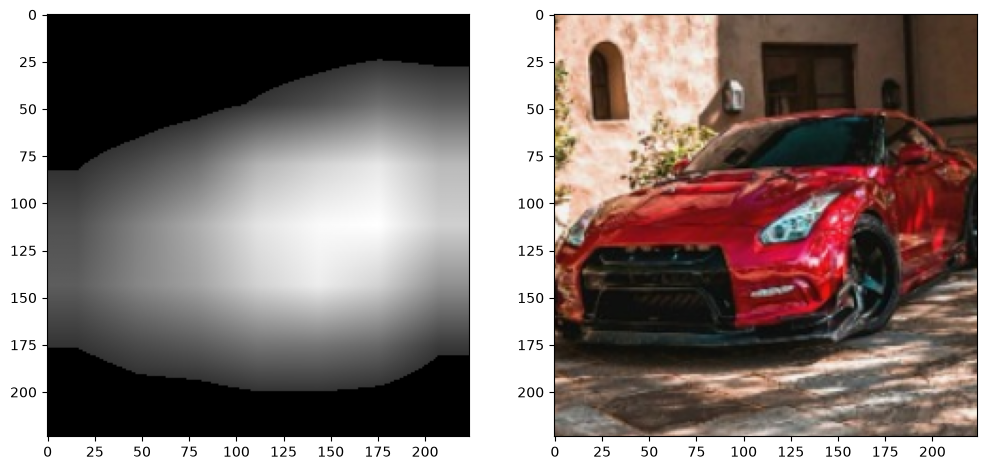

In [46]:
new_model.eval()
img_in = transforms(img).unsqueeze(dim=0)

feature_maps = new_model(img_in)
pred = feature_maps * weights.reshape((feature_maps.shape[1], 1, 1))
pred = pred.sum(dim=1, keepdim=True)

img_numpy = nn.Upsample(scale_factor=32, mode="bilinear")(pred).squeeze().detach().numpy()
mask = img_numpy > img_numpy.max() * 0.2
img_numpy = img_numpy * mask

img1 = transforms(img)
img1 = np.transpose(img1, axes=[1, 2, 0]) * np.array([[[0.229, 0.224, 0.225]]]) + np.array([[[0.485, 0.456, 0.406]]])

plt.rcParams['figure.figsize'] = [12, 6]
plt.subplot(1, 2, 1)
plt.imshow(img_numpy, cmap="gray")
plt.subplot(1, 2, 2)
plt.imshow(img1)

In [47]:
ys, xs = np.where(mask.squeeze())

x_min, x_max = xs.min(), xs.max()
y_min, y_max = ys.min(), ys.max()

print(x_min, x_max, y_min, y_max)

0 223 24 199


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9999999964237213].


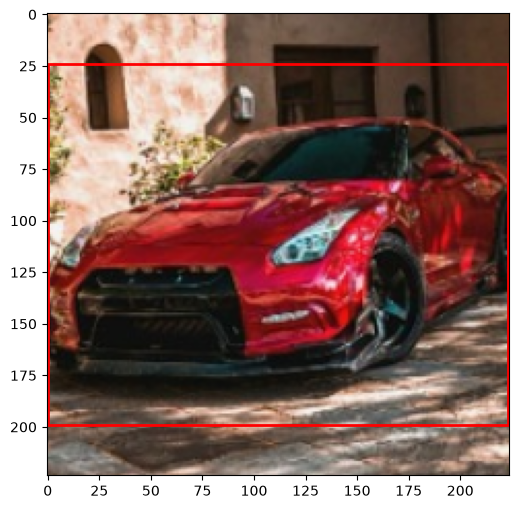

In [48]:
import matplotlib.patches as patches

fig, ax = plt.subplots(1, figsize=(6,6))

rect = patches.Rectangle(
    (x_min, y_min), x_max - x_min, y_max - y_min,
    linewidth=2, edgecolor="red", facecolor="none"
)

ax.imshow(img1)
ax.add_patch(rect)
plt.show()